In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
#Generating the dataset
def generate_dataset():
  x = np.arange(1, 101)
  np.random.seed(42)
  epsilon = np.random.normal(0, 1, 100)
  y = 3 + 5 * x + epsilon
  data = pd.DataFrame({
      "X": x,
      "Y": y
  })
  data.to_csv("lab01_data.csv", index = False)

generate_dataset()

In [45]:
#Adding dummy features x0 (with 1s) and re-writing the equation
def add_dummies():
  data = pd.read_csv("lab01_data.csv")
  x = data["X"]
  y = data["Y"]
  x0 = np.ones(len(x))
  X = np.array([x0, x]).T
  theta = np.array([3, 5])
  y_prime = X.dot(theta)
  print(y_prime)

add_dummies()

[  8.  13.  18.  23.  28.  33.  38.  43.  48.  53.  58.  63.  68.  73.
  78.  83.  88.  93.  98. 103. 108. 113. 118. 123. 128. 133. 138. 143.
 148. 153. 158. 163. 168. 173. 178. 183. 188. 193. 198. 203. 208. 213.
 218. 223. 228. 233. 238. 243. 248. 253. 258. 263. 268. 273. 278. 283.
 288. 293. 298. 303. 308. 313. 318. 323. 328. 333. 338. 343. 348. 353.
 358. 363. 368. 373. 378. 383. 388. 393. 398. 403. 408. 413. 418. 423.
 428. 433. 438. 443. 448. 453. 458. 463. 468. 473. 478. 483. 488. 493.
 498. 503.]


In [38]:
#Cost function
def cost_function(X, y, theta):
  m = len(y)
  y_pred = X.dot(theta)
  error = y_pred - y
  cost = (1 / (2*m))*np.sum(error**2)
  return cost

In [46]:
data = pd.read_csv("lab01_data.csv")
x = data["X"]
y = data["Y"]
x_mean = np.mean(x)
x_std = np.std(x)
x_scaled = (x - x_mean) / x_std
x0 = np.ones(len(x))
X = np.array([x0, x_scaled]).T
theta = np.array([0, 0])
cost = cost_function(X, y, theta)
print(cost)

43035.43553462359


In [47]:
#Gradient descent to reduce cost
def gradient_descent(X, y, theta, alpha, iters):
  m = len(y)
  cost_history = np.zeros(iters)
  for i in range(iters):
    y_pred = X.dot(theta)
    error = y_pred - y
    grad = (1 / m)*(X.T @ error)
    theta = theta - alpha * grad
    cost_history[i] = cost_function(X, y, theta)
  return theta, cost_history

Learned parameters:
[255.38512771 144.3643355 ]
0.4075325635667899


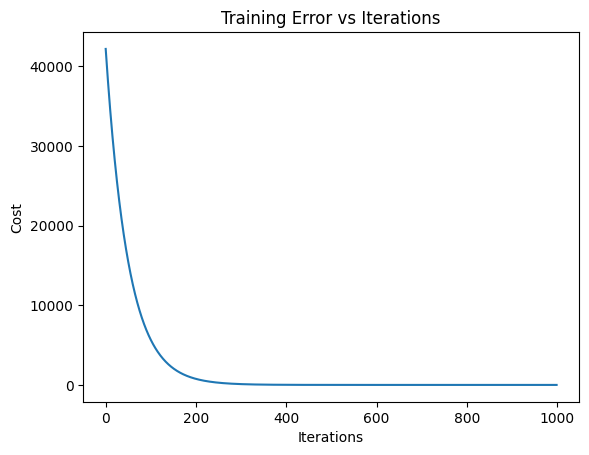

In [51]:
theta = np.array([0.0, 0.0])
learning_rate = 0.01
iters = 1000
theta, cost_history = gradient_descent(
    X,
    y,
    theta,
    learning_rate,
    iters
)
print("Learned parameters:")
print(theta)
print(cost_history[-1])
plt.plot(range(iters), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Error vs Iterations")
plt.show()

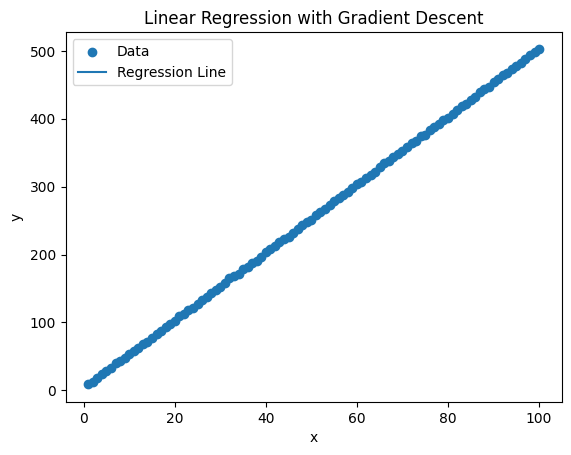

In [52]:
y_pred = X.dot(theta)

# Plot original data
plt.scatter(x, y, label="Data")

# Plot learned regression line
plt.plot(x, y_pred, label="Regression Line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Gradient Descent")
plt.legend()
plt.show()